[CircuitInstruction(operation=Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(2, 'q'), 0),), clbits=()), CircuitInstruction(operation=Instruction(name='ry', num_qubits=1, num_clbits=0, params=[2.901420183987569]), qubits=(Qubit(QuantumRegister(2, 'q'), 1),), clbits=()), CircuitInstruction(operation=Instruction(name='sdg', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(2, 'q'), 1),), clbits=()), CircuitInstruction(operation=Instruction(name='s', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(2, 'q'), 0),), clbits=()), CircuitInstruction(operation=Instruction(name='r', num_qubits=1, num_clbits=0, params=[4.696624235392817, 5.500911221490664]), qubits=(Qubit(QuantumRegister(2, 'q'), 0),), clbits=()), CircuitInstruction(operation=Instruction(name='sxdg', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(2, 'q'), 1),), clbits=()), CircuitInstruction(operation=Instruction(name='u', 

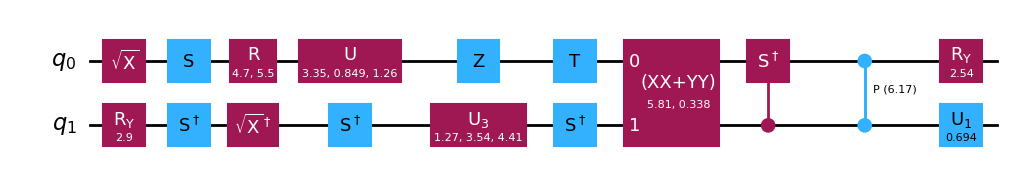

In [219]:
from qiskit import QuantumCircuit
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Statevector

qc = random_circuit(2, max_operands =2, depth = 10)
print(qc.data)
qc.draw('mpl')



In [152]:
# gate latex names and parameters
import json
import numpy as np
import pandas as pd

with open('gates.json', 'r') as file:
    quantum_gates = json.load(file)

def categorize_gate(gate_name):
    gate_name = gate_name.lower()
    for category, gates in quantum_gates.items():
        for gate in gates: 
            if gate_name == gate['name']: 
                return category, gate['latex']
names = []
params = []
idxs = []
categories = []
for instruction in qc.data: 
    category, latex = categorize_gate(instruction.operation.name)

    categories.append(category)
    names.append(latex)
    params.append([i for i in instruction.operation.params if isinstance(i, np.float64)])
    idxs.append([qc.find_bit(qubit).index for qubit in instruction.qubits])

circuit_data = pd.DataFrame({
    'category': categories,
    'names': names, 
    'params': params, 
    'idxs': idxs
})

In [153]:
display(circuit_data)

,category,names,params,idxs
0,single_qubit_gates,S,[],[0]
1,single_qubit_gates,I,[],[1]
2,cx_like_gates,CY,[],"[1, 0]"
3,multi_qubit_gates,XX + YY,"[5.374748011030326, 5.253020568829901]","[0, 1]"
4,general_controlled_gates,CR_x,[5.008800860371561],"[0, 1]"
5,cx_like_gates,CY,[],"[1, 0]"
6,single_qubit_gates,U,"[1.709044843052112, 2.9353199689051697, 4.5461...",[0]
7,single_qubit_gates,T,[],[1]
8,cphase_gates,CU,"[1.2361259977972268, 2.58910077411368, 3.59693...","[1, 0]"
9,single_qubit_gates,I,[],[1]


In [199]:
for i, j in circuit_data.iterrows(): 
    print(j.iloc[0])


single_qubit_gates
single_qubit_gates
cx_like_gates
multi_qubit_gates
general_controlled_gates
cx_like_gates
single_qubit_gates
single_qubit_gates
cphase_gates
single_qubit_gates
single_qubit_gates
multi_qubit_gates
cphase_gates


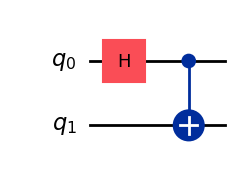

In [206]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

qc.draw('mpl')

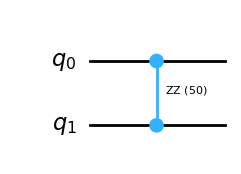

In [215]:
qc = QuantumCircuit(2)
qc.rzz(50, 0, 1)
qc.draw('mpl')

In [216]:
qc.data

[CircuitInstruction(operation=Instruction(name='rzz', num_qubits=2, num_clbits=0, params=[50]), qubits=(Qubit(QuantumRegister(2, 'q'), 0), Qubit(QuantumRegister(2, 'q'), 1)), clbits=())]